# 03 — Baseline Text-Conditioned Part Segmentation

## Goal

This notebook builds the first trainable segmentation models.

We use:

- Frozen DINOv2 ViT-S/14 as the visual encoder.
- Frozen CLIP ViT-B/32 as the text encoder.
- Small trainable visual/text projections.
- A lightweight segmentation decoder.

We train two controlled baselines.

### Experiment 1 — `part_only`

Input:

- DINOv2 visual features
- CLIP part-query embedding

Question:

> How well can frozen visual-language foundation features perform
> text-conditioned part segmentation without explicit parent-object information?

### Experiment 2 — `object_mask`

Input:

- DINOv2 visual features
- CLIP part-query embedding
- parent-object mask

Question:

> Does explicitly identifying the parent object improve part segmentation?

No X/Y coordinates, U/V coordinates, geometry, DINO-CLIP alignment,
rotation augmentation, or noisy-mask experiments are introduced yet.

In [1]:
from pathlib import Path
import sys
import json
import random
import time
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode

import open_clip

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT = PROJECT_ROOT.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation


In [3]:
from datasets import PascalPart116Dataset

print("PascalPart116Dataset imported successfully.")

PascalPart116Dataset imported successfully.


In [4]:
SEED = 42

IMAGE_SIZE = 224

TRAIN_BATCH_SIZE = 16
VAL_BATCH_SIZE = 16

NUM_WORKERS = 4

EPOCHS = 20

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

VISUAL_DIM = 128
TEXT_DIM = 32

MASK_THRESHOLD = 0.5

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = torch.cuda.is_available()

OUTPUT_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "experiments"
)

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

print("Device:", DEVICE)
print("AMP:", USE_AMP)
print("Output root:", OUTPUT_ROOT)

Device: cuda
AMP: True
Output root: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments


In [5]:
def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)

print("Seed:", SEED)

Seed: 42


In [6]:
raw_train_dataset = PascalPart116Dataset(
    split="train_seen"
)

raw_val_dataset = PascalPart116Dataset(
    split="validation_seen"
)

raw_test_seen_dataset = PascalPart116Dataset(
    split="test_seen"
)

raw_test_unseen_dataset = PascalPart116Dataset(
    split="test_unseen"
)

print("Train:", len(raw_train_dataset))
print("Validation:", len(raw_val_dataset))
print("Test seen:", len(raw_test_seen_dataset))
print("Test unseen:", len(raw_test_unseen_dataset))

Train: 32698
Validation: 3708
Test seen: 3371
Test unseen: 1586


## Model Preprocessing

The pure dataset intentionally keeps original image resolution.

For model training we now need fixed-size samples.

We use:

1. aspect-ratio-preserving resize;
2. padding to 224 × 224;
3. ImageNet normalization for DINOv2;
4. nearest-neighbour resizing for binary masks.


The RGB image and masks must receive exactly the same geometric transformation.

In [7]:
IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32,
).view(3, 1, 1)

IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32,
).view(3, 1, 1)

In [8]:
def get_resize_info(
    height,
    width,
    target_size=224,
):

    scale = min(
        target_size / height,
        target_size / width,
    )

    new_h = max(
        1,
        round(height * scale),
    )

    new_w = max(
        1,
        round(width * scale),
    )

    pad_h = target_size - new_h
    pad_w = target_size - new_w

    top = pad_h // 2
    bottom = pad_h - top

    left = pad_w // 2
    right = pad_w - left

    return {
        "new_h": new_h,
        "new_w": new_w,
        "top": top,
        "bottom": bottom,
        "left": left,
        "right": right,
        "scale": scale,
    }

In [9]:
def preprocess_image(
    image,
    target_size=224,
):

    image = image.float() / 255.0

    _, h, w = image.shape

    info = get_resize_info(
        h,
        w,
        target_size,
    )

    resized = TF.resize(
        image,
        [
            info["new_h"],
            info["new_w"],
        ],
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    )

    # Visualization copy
    display_image = F.pad(
        resized,
        (
            info["left"],
            info["right"],
            info["top"],
            info["bottom"],
        ),
        value=0.0,
    )

    # Normalize before padding.
    normalized = (
        resized - IMAGENET_MEAN
    ) / IMAGENET_STD

    # 0 in normalized space is approximately
    # the ImageNet mean.
    model_image = F.pad(
        normalized,
        (
            info["left"],
            info["right"],
            info["top"],
            info["bottom"],
        ),
        value=0.0,
    )

    return (
        display_image,
        model_image,
        info,
    )

In [10]:
def preprocess_mask(
    mask,
    resize_info,
    preserve_positive=False,
):

    if mask.ndim == 2:
        mask = mask.unsqueeze(0)

    mask = mask.float()

    resized = TF.resize(
        mask,
        [
            resize_info["new_h"],
            resize_info["new_w"],
        ],
        interpolation=InterpolationMode.NEAREST,
    )

    if (
        preserve_positive
        and mask.sum() > 0
        and resized.sum() == 0
    ):
        resized = F.interpolate(
            mask.unsqueeze(0),
            size=(
                resize_info["new_h"],
                resize_info["new_w"],
            ),
            mode="area",
        ).squeeze(0)

        resized = (
            resized > 0
        ).float()

    padded = F.pad(
        resized,
        (
            resize_info["left"],
            resize_info["right"],
            resize_info["top"],
            resize_info["bottom"],
        ),
        value=0.0,
    )

    return padded > 0.5

In [11]:
class SegmentationDataset(Dataset):

    def __init__(
        self,
        split,
        image_size=224,
    ):

        self.base_dataset = (
            PascalPart116Dataset(
                split=split
            )
        )

        self.image_size = image_size

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, index):

        sample = self.base_dataset[index]

        (
            display_image,
            image,
            resize_info,
        ) = preprocess_image(
            sample["image"],
            self.image_size,
        )

        object_mask = preprocess_mask(
            sample["object_mask"],
            resize_info,
            preserve_positive=True,
        )

        part_mask = preprocess_mask(
            sample["part_mask"],
            resize_info,
            preserve_positive=True,
        )

        # Part is expected to belong to parent object.
        overlap = (
            part_mask
            & object_mask
        )

        # Normally this is already non-empty.
        # If the tiny target was affected differently
        # by resizing, preserve its known containment.
        if (
            part_mask.any()
            and not overlap.any()
        ):
            object_mask = (
                object_mask
                | part_mask
            )

        part_mask = (
            part_mask
            & object_mask
        )

        return {
            "sample_id": sample["sample_id"],
            "image_id": sample["image_id"],

            "image": image,

            "display_image": display_image,

            "object_mask": (
                object_mask.float()
            ),

            "part_mask": (
                part_mask.float()
            ),

            "query": sample["query"],
            "part_name": sample["part_name"],
            "object_name": sample["object_name"],

            "evaluation_split": (
                sample["evaluation_split"]
            ),
        }

In [12]:
train_dataset = SegmentationDataset(
    split="train_seen",
    image_size=IMAGE_SIZE,
)

val_dataset = SegmentationDataset(
    split="validation_seen",
    image_size=IMAGE_SIZE,
)

test_seen_dataset = SegmentationDataset(
    split="test_seen",
    image_size=IMAGE_SIZE,
)

test_unseen_dataset = SegmentationDataset(
    split="test_unseen",
    image_size=IMAGE_SIZE,
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Seen test:", len(test_seen_dataset))
print("Unseen test:", len(test_unseen_dataset))

Train: 32698
Validation: 3708
Seen test: 3371
Unseen test: 1586


In [13]:
sample = train_dataset[0]

for key, value in sample.items():

    if torch.is_tensor(value):
        print(
            f"{key:20s}",
            tuple(value.shape),
            value.dtype,
        )
    else:
        print(
            f"{key:20s}",
            value,
        )

sample_id            train:2008_000002:part_115
image_id             2008_000002
image                (3, 224, 224) torch.float32
display_image        (3, 224, 224) torch.float32
object_mask          (1, 224, 224) torch.float32
part_mask            (1, 224, 224) torch.float32
query                screen
part_name            screen
object_name          tvmonitor
evaluation_split     seen


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].


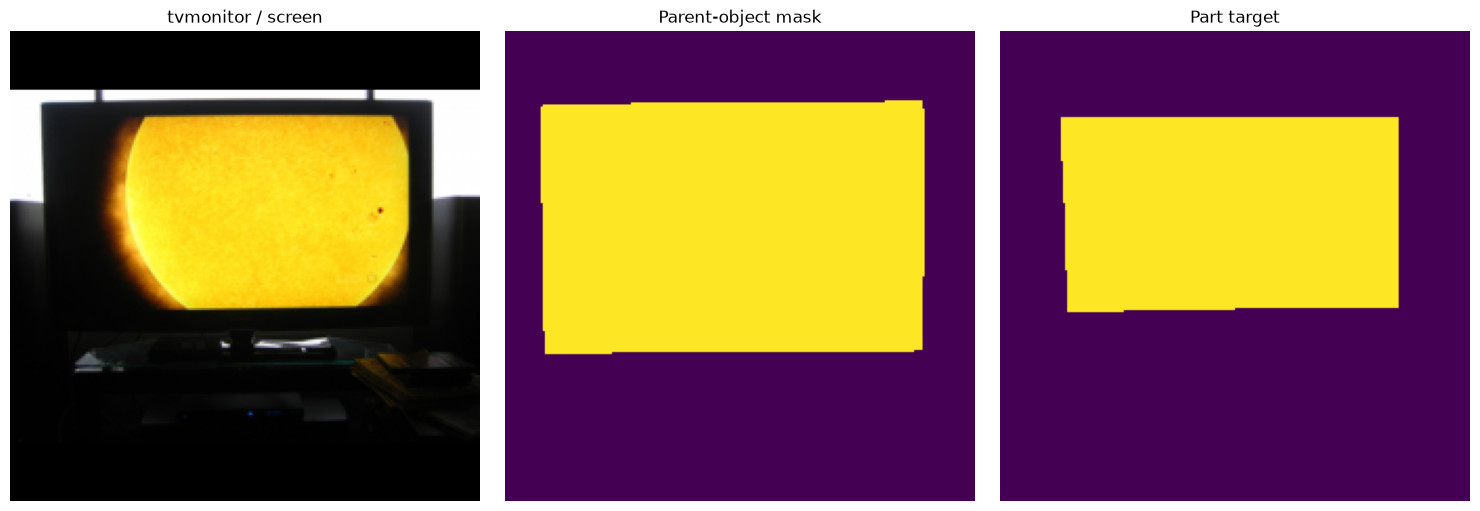

In [14]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
)

axes[0].imshow(
    sample["display_image"]
    .permute(1, 2, 0)
    .numpy()
)

axes[0].set_title(
    f"{sample['object_name']} / "
    f"{sample['part_name']}"
)

axes[1].imshow(
    sample["object_mask"].squeeze()
)

axes[1].set_title(
    "Parent-object mask"
)

axes[2].imshow(
    sample["part_mask"].squeeze()
)

axes[2].set_title(
    "Part target"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
rng = random.Random(SEED)

indices = rng.sample(
    range(len(train_dataset)),
    min(
        200,
        len(train_dataset),
    ),
)

empty_targets = 0
containment_errors = 0

for idx in indices:

    s = train_dataset[idx]

    obj = (
        s["object_mask"] > 0.5
    )

    part = (
        s["part_mask"] > 0.5
    )

    if not part.any():
        empty_targets += 1

    if not torch.all(
        ~part | obj
    ):
        containment_errors += 1


print(
    "Samples checked:",
    len(indices)
)

print(
    "Empty target masks:",
    empty_targets
)

print(
    "Containment errors:",
    containment_errors
)

Samples checked: 200
Empty target masks: 0
Containment errors: 0


In [16]:
PIN_MEMORY = (
    DEVICE.type == "cuda"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_seen_loader = DataLoader(
    test_seen_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_unseen_loader = DataLoader(
    test_unseen_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

In [17]:
batch = next(
    iter(train_loader)
)

print(
    "Image:",
    batch["image"].shape
)

print(
    "Object mask:",
    batch["object_mask"].shape
)

print(
    "Part mask:",
    batch["part_mask"].shape
)

print(
    "Queries:",
    batch["query"][:5]
)

Image: torch.Size([16, 3, 224, 224])
Object mask: torch.Size([16, 1, 224, 224])
Part mask: torch.Size([16, 1, 224, 224])
Queries: ['torso', 'nose', 'screen', 'upper arm', 'head']


In [18]:
dino = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vits14",
)

dino = dino.to(DEVICE)

dino.eval()

for parameter in dino.parameters():
    parameter.requires_grad = False


print("DINOv2 loaded and frozen.")

Using cache found in /home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main
/home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 loaded and frozen.


In [19]:
clip_model, _, _ = (
    open_clip.create_model_and_transforms(
        "ViT-B-32",
        pretrained="openai",
    )
)

clip_tokenizer = (
    open_clip.get_tokenizer(
        "ViT-B-32"
    )
)

clip_model = (
    clip_model
    .to(DEVICE)
)

clip_model.eval()

for parameter in clip_model.parameters():
    parameter.requires_grad = False

print("CLIP loaded and frozen.")

/home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/.venv/lib/python3.12/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP loaded and frozen.


In [20]:
print(
    "DINO trainable parameters:",
    sum(
        p.numel()
        for p in dino.parameters()
        if p.requires_grad
    )
)

print(
    "CLIP trainable parameters:",
    sum(
        p.numel()
        for p in clip_model.parameters()
        if p.requires_grad
    )
)

DINO trainable parameters: 0
CLIP trainable parameters: 0


In [21]:
class TextEmbeddingCache:

    def __init__(
        self,
        model,
        tokenizer,
        device,
    ):

        self.model = model
        self.tokenizer = tokenizer
        self.device = device

        self.cache = {}

    @torch.no_grad()
    def _encode_missing(
        self,
        queries,
    ):

        missing = sorted(
            set(
                q
                for q in queries
                if q not in self.cache
            )
        )

        if not missing:
            return

        prompts = [
            f"a photo of the {q} of an object"
            for q in missing
        ]

        tokens = self.tokenizer(
            prompts
        ).to(
            self.device
        )

        embeddings = (
            self.model.encode_text(
                tokens
            )
        )

        embeddings = F.normalize(
            embeddings.float(),
            dim=-1,
        )

        for query, embedding in zip(
            missing,
            embeddings,
        ):

            self.cache[query] = (
                embedding
                .detach()
                .cpu()
            )

    def __call__(
        self,
        queries,
    ):

        self._encode_missing(
            queries
        )

        embeddings = torch.stack(
            [
                self.cache[q]
                for q in queries
            ]
        )

        return embeddings.to(
            self.device,
            non_blocking=True,
        )

In [22]:
text_encoder = TextEmbeddingCache(
    clip_model,
    clip_tokenizer,
    DEVICE,
)

In [23]:
example_embeddings = text_encoder(
    [
        "wheel",
        "head",
        "wheel",
    ]
)

print(
    example_embeddings.shape
)

print(
    "Cached queries:",
    list(
        text_encoder.cache.keys()
    )
)

torch.Size([3, 512])
Cached queries: ['head', 'wheel']


# Baseline Architecture

DINOv2 produces:

[B, 384, 16, 16]

A trainable 1×1 convolution projects this to:

[B, 128, 16, 16]

CLIP produces:

[B, 512]

A small trainable projection converts this to:

[B, 32]

The text representation is broadcast over the 16×16 image grid:

[B, 32, 16, 16]

For controlled comparison, the decoder always receives one additional
mask channel.

In `part_only`, this channel contains zeros.

In `object_mask`, this channel contains the resized parent-object mask.

Therefore both models have exactly the same decoder architecture and
number of parameters.

In [24]:
class BaselinePartSegmenter(nn.Module):

    def __init__(
        self,
        dino_encoder,
        mode="part_only",
        visual_dim=128,
        text_dim=32,
    ):

        super().__init__()

        assert mode in {
            "part_only",
            "object_mask",
        }

        self.mode = mode

        self.dino = dino_encoder

        for p in self.dino.parameters():
            p.requires_grad = False

        # DINO ViT-S/14:
        # 384 -> 128
        self.visual_projection = (
            nn.Conv2d(
                384,
                visual_dim,
                kernel_size=1,
            )
        )

        # CLIP:
        # 512 -> 32
        self.text_projection = (
            nn.Sequential(
                nn.Linear(
                    512,
                    64,
                ),
                nn.GELU(),
                nn.Linear(
                    64,
                    text_dim,
                ),
            )
        )

        fusion_dim = (
            visual_dim
            + text_dim
            + 1
        )

        self.decoder = nn.Sequential(

            nn.Conv2d(
                fusion_dim,
                128,
                kernel_size=3,
                padding=1,
            ),

            nn.GroupNorm(
                8,
                128,
            ),

            nn.GELU(),

            nn.Conv2d(
                128,
                64,
                kernel_size=3,
                padding=1,
            ),

            nn.GroupNorm(
                8,
                64,
            ),

            nn.GELU(),

            nn.Conv2d(
                64,
                32,
                kernel_size=3,
                padding=1,
            ),

            nn.GELU(),

            nn.Conv2d(
                32,
                1,
                kernel_size=1,
            ),
        )

    def train(
        self,
        mode=True,
    ):

        super().train(mode)

        # DINO must always remain in eval mode.
        self.dino.eval()

        return self

    def extract_dino_features(
        self,
        images,
    ):

        with torch.no_grad():

            output = (
                self.dino.forward_features(
                    images
                )
            )

            patch_tokens = output[
                "x_norm_patchtokens"
            ]

        b, n, c = (
            patch_tokens.shape
        )

        grid = int(
            n ** 0.5
        )

        features = (
            patch_tokens
            .transpose(1, 2)
            .reshape(
                b,
                c,
                grid,
                grid,
            )
        )

        return features

    def forward(
        self,
        images,
        text_embeddings,
        object_mask,
    ):

        dino_features = (
            self.extract_dino_features(
                images
            )
        )

        visual = (
            self.visual_projection(
                dino_features
            )
        )

        text = (
            self.text_projection(
                text_embeddings
            )
        )

        text_map = (
            text[:, :, None, None]
            .expand(
                -1,
                -1,
                visual.shape[-2],
                visual.shape[-1],
            )
        )

        mask_low = F.interpolate(
            object_mask,
            size=visual.shape[-2:],
            mode="nearest",
        )

        if self.mode == "part_only":

            mask_low = torch.zeros_like(
                mask_low
            )

        fused = torch.cat(
            [
                visual,
                text_map,
                mask_low,
            ],
            dim=1,
        )

        logits_low = (
            self.decoder(
                fused
            )
        )

        logits = F.interpolate(
            logits_low,
            size=images.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        return logits

## Why is the object mask only concatenated?

For this first controlled experiment we do NOT multiply the DINO features
by the object mask.

Doing that would introduce two changes simultaneously:

1. providing the object mask;
2. forcibly removing visual information outside the object.

Instead, both models receive exactly the same DINO features.

The only difference is:

`part_only`

mask channel = 0

versus

`object_mask`

mask channel = real parent-object mask

This makes the ablation easier to interpret.

In [25]:
test_model = BaselinePartSegmenter(
    dino_encoder=dino,
    mode="part_only",
    visual_dim=VISUAL_DIM,
    text_dim=TEXT_DIM,
).to(
    DEVICE
)

In [26]:
total_parameters = sum(
    p.numel()
    for p in test_model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in test_model.parameters()
    if p.requires_grad
)

print(
    f"Total parameters including frozen DINO: "
    f"{total_parameters:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_parameters:,}"
)

Total parameters including frozen DINO: 22,419,041
Trainable parameters: 362,465


In [27]:
batch = next(
    iter(train_loader)
)

images = batch[
    "image"
].to(
    DEVICE
)

object_masks = batch[
    "object_mask"
].to(
    DEVICE
)

text_embeddings = text_encoder(
    batch["query"]
)

with torch.no_grad():

    logits = test_model(
        images,
        text_embeddings,
        object_masks,
    )

print(
    "Images:",
    images.shape
)

print(
    "Text:",
    text_embeddings.shape
)

print(
    "Output:",
    logits.shape
)

Images: torch.Size([16, 3, 224, 224])
Text: torch.Size([16, 512])
Output: torch.Size([16, 1, 224, 224])


In [28]:
single_image = (
    images[:1]
)

single_mask = (
    object_masks[:1]
)

wheel_embedding = text_encoder(
    ["wheel"]
)

head_embedding = text_encoder(
    ["head"]
)

with torch.no_grad():

    pred_wheel = test_model(
        single_image,
        wheel_embedding,
        single_mask,
    )

    pred_head = test_model(
        single_image,
        head_embedding,
        single_mask,
    )

difference = (
    pred_wheel - pred_head
).abs().mean()

print(
    "Mean prediction difference:",
    difference.item()
)

Mean prediction difference: 6.67005151626654e-05


In [29]:
def dice_loss(
    logits,
    targets,
    eps=1e-6,
):

    probabilities = torch.sigmoid(
        logits
    )

    probabilities = (
        probabilities.flatten(1)
    )

    targets = (
        targets.flatten(1)
    )

    intersection = (
        probabilities
        * targets
    ).sum(
        dim=1
    )

    denominator = (
        probabilities.sum(dim=1)
        + targets.sum(dim=1)
    )

    dice = (
        2 * intersection + eps
    ) / (
        denominator + eps
    )

    return (
        1 - dice
    ).mean()

In [30]:
def segmentation_loss(
    logits,
    targets,
):

    bce = F.binary_cross_entropy_with_logits(
        logits,
        targets,
    )

    dice = dice_loss(
        logits,
        targets,
    )

    total = (
        bce + dice
    )

    return {
        "total": total,
        "bce": bce,
        "dice": dice,
    }

In [31]:
targets = batch[
    "part_mask"
].to(
    DEVICE
)

losses = segmentation_loss(
    logits,
    targets,
)

for key, value in losses.items():
    print(
        key,
        value.item()
    )

total 1.6534159183502197
bce 0.6954510807991028
dice 0.9579648971557617


In [32]:
@torch.no_grad()
def batch_iou(
    logits,
    targets,
    threshold=0.5,
    eps=1e-6,
):

    probabilities = torch.sigmoid(
        logits
    )

    predictions = (
        probabilities >= threshold
    )

    targets = (
        targets >= 0.5
    )

    predictions = (
        predictions.flatten(1)
    )

    targets = (
        targets.flatten(1)
    )

    intersection = (
        predictions
        & targets
    ).sum(
        dim=1
    ).float()

    union = (
        predictions
        | targets
    ).sum(
        dim=1
    ).float()

    iou = (
        intersection + eps
    ) / (
        union + eps
    )

    return iou

In [33]:
@torch.no_grad()
def batch_dice(
    logits,
    targets,
    threshold=0.5,
    eps=1e-6,
):

    probabilities = torch.sigmoid(
        logits
    )

    predictions = (
        probabilities >= threshold
    )

    targets = (
        targets >= 0.5
    )

    predictions = (
        predictions.flatten(1)
    )

    targets = (
        targets.flatten(1)
    )

    intersection = (
        predictions
        & targets
    ).sum(
        dim=1
    ).float()

    denominator = (
        predictions.sum(dim=1)
        + targets.sum(dim=1)
    ).float()

    dice = (
        2 * intersection + eps
    ) / (
        denominator + eps
    )

    return dice

In [34]:
iou_values = batch_iou(
    logits,
    targets,
)

dice_values = batch_dice(
    logits,
    targets,
)

print(
    "Mean IoU:",
    iou_values.mean().item()
)

print(
    "Mean Dice:",
    dice_values.mean().item()
)

Mean IoU: 0.026157032698392868
Mean Dice: 0.045505594462156296


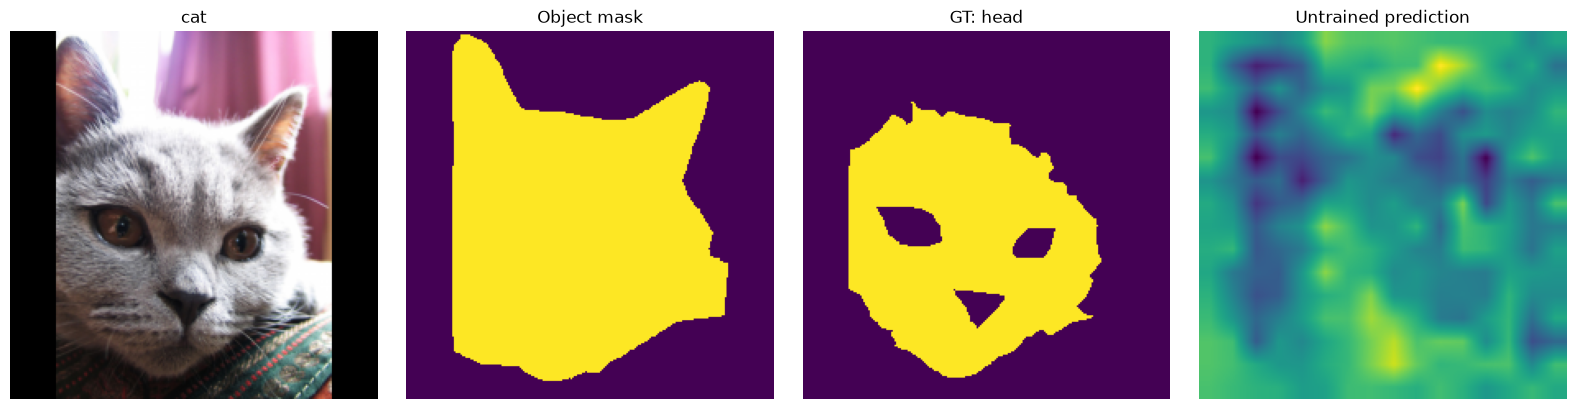

In [35]:
idx = 0

probability = (
    torch.sigmoid(
        logits[idx]
    )
    .detach()
    .cpu()
    .squeeze()
)

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4),
)

axes[0].imshow(
    batch[
        "display_image"
    ][idx]
    .permute(1, 2, 0)
)

axes[0].set_title(
    f"{batch['object_name'][idx]}"
)

axes[1].imshow(
    batch[
        "object_mask"
    ][idx]
    .squeeze()
)

axes[1].set_title(
    "Object mask"
)

axes[2].imshow(
    batch[
        "part_mask"
    ][idx]
    .squeeze()
)

axes[2].set_title(
    f"GT: {batch['query'][idx]}"
)

axes[3].imshow(
    probability
)

axes[3].set_title(
    "Untrained prediction"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [36]:
del test_model

if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [37]:
debug_model = BaselinePartSegmenter(
    dino_encoder=dino,
    mode="part_only",
    visual_dim=VISUAL_DIM,
    text_dim=TEXT_DIM,
).to(
    DEVICE
)

debug_optimizer = torch.optim.AdamW(
    (
        p
        for p in debug_model.parameters()
        if p.requires_grad
    ),
    lr=1e-3,
)

In [38]:
debug_batch = next(
    iter(
        DataLoader(
            train_dataset,
            batch_size=4,
            shuffle=False,
            num_workers=0,
        )
    )
)

debug_images = (
    debug_batch["image"]
    .to(DEVICE)
)

debug_masks = (
    debug_batch["object_mask"]
    .to(DEVICE)
)

debug_targets = (
    debug_batch["part_mask"]
    .to(DEVICE)
)

debug_text = text_encoder(
    debug_batch["query"]
)

print(
    debug_batch["query"]
)

['screen', 'torso', 'leg', 'body']


In [39]:
debug_losses = []

for step in range(100):

    debug_model.train()

    debug_optimizer.zero_grad(
        set_to_none=True
    )

    logits_debug = debug_model(
        debug_images,
        debug_text,
        debug_masks,
    )

    losses = segmentation_loss(
        logits_debug,
        debug_targets,
    )

    losses["total"].backward()

    debug_optimizer.step()

    debug_losses.append(
        losses["total"].item()
    )

    if (
        step == 0
        or (step + 1) % 20 == 0
    ):
        print(
            f"Step {step+1:3d} | "
            f"Loss {losses['total'].item():.4f}"
        )

Step   1 | Loss 1.5508
Step  20 | Loss 0.5861
Step  40 | Loss 0.5506
Step  60 | Loss 0.5060
Step  80 | Loss 0.4082
Step 100 | Loss 0.3638


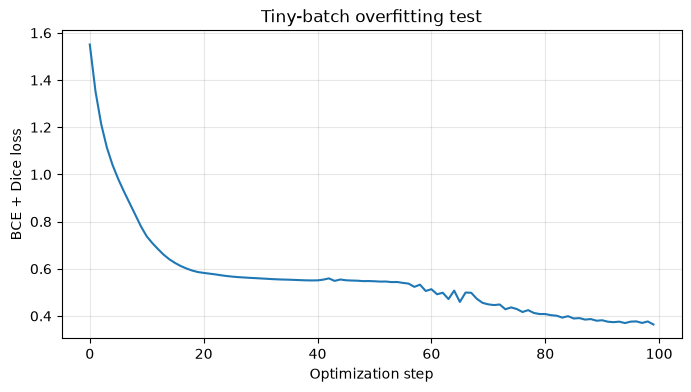

In [41]:
plt.figure(
    figsize=(8, 4)
)

plt.plot(
    debug_losses
)

plt.xlabel(
    "Optimization step"
)

plt.ylabel(
    "BCE + Dice loss"
)

plt.title(
    "Tiny-batch overfitting test"
)

plt.grid(
    alpha=0.3
)

plt.show()

In [42]:
debug_model.eval()

with torch.no_grad():

    debug_logits = debug_model(
        debug_images,
        debug_text,
        debug_masks,
    )

print(
    "Debug IoU:",
    batch_iou(
        debug_logits,
        debug_targets,
    ).mean().item()
)

print(
    "Debug Dice:",
    batch_dice(
        debug_logits,
        debug_targets,
    ).mean().item()
)

Debug IoU: 0.5875199437141418
Debug Dice: 0.6676755547523499


In [43]:
del debug_model
del debug_optimizer

if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [44]:
def run_epoch(
    model,
    loader,
    text_encoder,
    optimizer=None,
    scaler=None,
    threshold=0.5,
    max_batches=None,
):

    training = (
        optimizer is not None
    )

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_bce = 0.0
    total_dice_loss = 0.0

    total_iou = 0.0
    total_dice_metric = 0.0

    total_samples = 0

    for batch_index, batch in enumerate(
        loader
    ):

        if (
            max_batches is not None
            and batch_index >= max_batches
        ):
            break

        images = (
            batch["image"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        object_masks = (
            batch["object_mask"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        targets = (
            batch["part_mask"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        text_embeddings = (
            text_encoder(
                batch["query"]
            )
        )

        batch_size = (
            images.shape[0]
        )

        if training:

            optimizer.zero_grad(
                set_to_none=True
            )

        with torch.set_grad_enabled(
            training
        ):

            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):

                logits = model(
                    images,
                    text_embeddings,
                    object_masks,
                )

                losses = (
                    segmentation_loss(
                        logits,
                        targets,
                    )
                )

            if training:

                if scaler is not None:

                    scaler.scale(
                        losses["total"]
                    ).backward()

                    scaler.unscale_(
                        optimizer
                    )

                    torch.nn.utils.clip_grad_norm_(
                        (
                            p
                            for p
                            in model.parameters()
                            if p.requires_grad
                        ),
                        max_norm=1.0,
                    )

                    scaler.step(
                        optimizer
                    )

                    scaler.update()

                else:

                    losses[
                        "total"
                    ].backward()

                    torch.nn.utils.clip_grad_norm_(
                        (
                            p
                            for p
                            in model.parameters()
                            if p.requires_grad
                        ),
                        max_norm=1.0,
                    )

                    optimizer.step()

        with torch.no_grad():

            iou = batch_iou(
                logits,
                targets,
                threshold,
            )

            dice_metric = batch_dice(
                logits,
                targets,
                threshold,
            )

        total_loss += (
            losses["total"].item()
            * batch_size
        )

        total_bce += (
            losses["bce"].item()
            * batch_size
        )

        total_dice_loss += (
            losses["dice"].item()
            * batch_size
        )

        total_iou += (
            iou.sum().item()
        )

        total_dice_metric += (
            dice_metric.sum().item()
        )

        total_samples += (
            batch_size
        )

    return {
        "loss": (
            total_loss
            / total_samples
        ),
        "bce": (
            total_bce
            / total_samples
        ),
        "dice_loss": (
            total_dice_loss
            / total_samples
        ),
        "iou": (
            total_iou
            / total_samples
        ),
        "dice": (
            total_dice_metric
            / total_samples
        ),
    }

In [45]:
def get_trainable_state(
    model,
):

    return {
        "visual_projection": (
            model.visual_projection
            .state_dict()
        ),

        "text_projection": (
            model.text_projection
            .state_dict()
        ),

        "decoder": (
            model.decoder
            .state_dict()
        ),
    }

In [46]:
def load_trainable_state(
    model,
    checkpoint,
):

    model.visual_projection.load_state_dict(
        checkpoint[
            "model_state"
        ][
            "visual_projection"
        ]
    )

    model.text_projection.load_state_dict(
        checkpoint[
            "model_state"
        ][
            "text_projection"
        ]
    )

    model.decoder.load_state_dict(
        checkpoint[
            "model_state"
        ][
            "decoder"
        ]
    )

In [47]:
def train_experiment(
    mode,
    epochs=20,
):

    seed_everything(
        SEED
    )

    experiment_dir = (
        OUTPUT_ROOT
        / mode
    )

    experiment_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    model = BaselinePartSegmenter(
        dino_encoder=dino,
        mode=mode,
        visual_dim=VISUAL_DIM,
        text_dim=TEXT_DIM,
    ).to(
        DEVICE
    )

    optimizer = torch.optim.AdamW(
        (
            p
            for p in model.parameters()
            if p.requires_grad
        ),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = (
        torch.optim.lr_scheduler
        .ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2,
        )
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP,
    )

    config = {
        "mode": mode,
        "seed": SEED,
        "image_size": IMAGE_SIZE,
        "epochs": epochs,
        "train_batch_size": (
            TRAIN_BATCH_SIZE
        ),
        "val_batch_size": (
            VAL_BATCH_SIZE
        ),
        "learning_rate": (
            LEARNING_RATE
        ),
        "weight_decay": (
            WEIGHT_DECAY
        ),
        "visual_dim": (
            VISUAL_DIM
        ),
        "text_dim": (
            TEXT_DIM
        ),
        "mask_threshold": (
            MASK_THRESHOLD
        ),
        "dino": (
            "dinov2_vits14"
        ),
        "clip": (
            "ViT-B-32/openai"
        ),
    }

    with open(
        experiment_dir
        / "config.json",
        "w",
    ) as f:

        json.dump(
            config,
            f,
            indent=2,
        )

    history = []

    best_val_iou = -1.0

    for epoch in range(
        1,
        epochs + 1,
    ):

        start = time.time()

        train_metrics = run_epoch(
            model,
            train_loader,
            text_encoder,
            optimizer=optimizer,
            scaler=scaler,
            threshold=MASK_THRESHOLD,
        )

        with torch.no_grad():

            val_metrics = run_epoch(
                model,
                val_loader,
                text_encoder,
                optimizer=None,
                scaler=None,
                threshold=MASK_THRESHOLD,
            )

        scheduler.step(
            val_metrics["iou"]
        )

        elapsed = (
            time.time()
            - start
        )

        current_lr = (
            optimizer.param_groups[0][
                "lr"
            ]
        )

        row = {
            "epoch": epoch,

            "train_loss": (
                train_metrics["loss"]
            ),

            "train_iou": (
                train_metrics["iou"]
            ),

            "train_dice": (
                train_metrics["dice"]
            ),

            "val_loss": (
                val_metrics["loss"]
            ),

            "val_iou": (
                val_metrics["iou"]
            ),

            "val_dice": (
                val_metrics["dice"]
            ),

            "learning_rate": (
                current_lr
            ),

            "seconds": (
                elapsed
            ),
        }

        history.append(
            row
        )

        print(
            f"[{mode}] "
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_metrics['loss']:.4f} | "
            f"train IoU {train_metrics['iou']:.4f} | "
            f"val loss {val_metrics['loss']:.4f} | "
            f"val IoU {val_metrics['iou']:.4f} | "
            f"val Dice {val_metrics['dice']:.4f} | "
            f"{elapsed:.1f}s"
        )

        checkpoint = {
            "epoch": epoch,
            "mode": mode,

            "model_state": (
                get_trainable_state(
                    model
                )
            ),

            "optimizer_state": (
                optimizer.state_dict()
            ),

            "scheduler_state": (
                scheduler.state_dict()
            ),

            "val_metrics": (
                val_metrics
            ),

            "config": (
                config
            ),
        }

        torch.save(
            checkpoint,
            experiment_dir
            / "last.pt",
        )

        if (
            val_metrics["iou"]
            > best_val_iou
        ):

            best_val_iou = (
                val_metrics["iou"]
            )

            torch.save(
                checkpoint,
                experiment_dir
                / "best.pt",
            )

            print(
                "  -> saved new best checkpoint"
            )

        with open(
            experiment_dir
            / "history.json",
            "w",
        ) as f:

            json.dump(
                history,
                f,
                indent=2,
            )

    return (
        model,
        history,
    )

In [48]:
smoke_model = BaselinePartSegmenter(
    dino_encoder=dino,
    mode="part_only",
    visual_dim=VISUAL_DIM,
    text_dim=TEXT_DIM,
).to(
    DEVICE
)

smoke_optimizer = torch.optim.AdamW(
    (
        p
        for p in smoke_model.parameters()
        if p.requires_grad
    ),
    lr=LEARNING_RATE,
)

smoke_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP,
)

smoke_metrics = run_epoch(
    smoke_model,
    train_loader,
    text_encoder,
    optimizer=smoke_optimizer,
    scaler=smoke_scaler,
    max_batches=2,
)

print(smoke_metrics)

{'loss': 1.534876823425293, 'bce': 0.5716196596622467, 'dice_loss': 0.9632571041584015, 'iou': 0.008248248745630349, 'dice': 0.015485274282227124}


In [49]:
del smoke_model
del smoke_optimizer
del smoke_scaler

if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [50]:
part_only_model, part_only_history = (
    train_experiment(
        mode="part_only",
        epochs=EPOCHS,
    )
)

[part_only] Epoch 01/20 | train loss 0.8665 | train IoU 0.1495 | val loss 0.7998 | val IoU 0.1990 | val Dice 0.2773 | 172.8s
  -> saved new best checkpoint
[part_only] Epoch 02/20 | train loss 0.7794 | train IoU 0.2137 | val loss 0.7594 | val IoU 0.2266 | val Dice 0.3094 | 110.0s
  -> saved new best checkpoint
[part_only] Epoch 03/20 | train loss 0.7481 | train IoU 0.2368 | val loss 0.7455 | val IoU 0.2388 | val Dice 0.3237 | 110.1s
  -> saved new best checkpoint
[part_only] Epoch 04/20 | train loss 0.7229 | train IoU 0.2550 | val loss 0.7272 | val IoU 0.2509 | val Dice 0.3382 | 113.2s
  -> saved new best checkpoint
[part_only] Epoch 05/20 | train loss 0.7037 | train IoU 0.2691 | val loss 0.7170 | val IoU 0.2556 | val Dice 0.3424 | 109.9s
  -> saved new best checkpoint
[part_only] Epoch 06/20 | train loss 0.6854 | train IoU 0.2833 | val loss 0.7108 | val IoU 0.2606 | val Dice 0.3473 | 108.3s
  -> saved new best checkpoint
[part_only] Epoch 07/20 | train loss 0.6719 | train IoU 0.2938 |

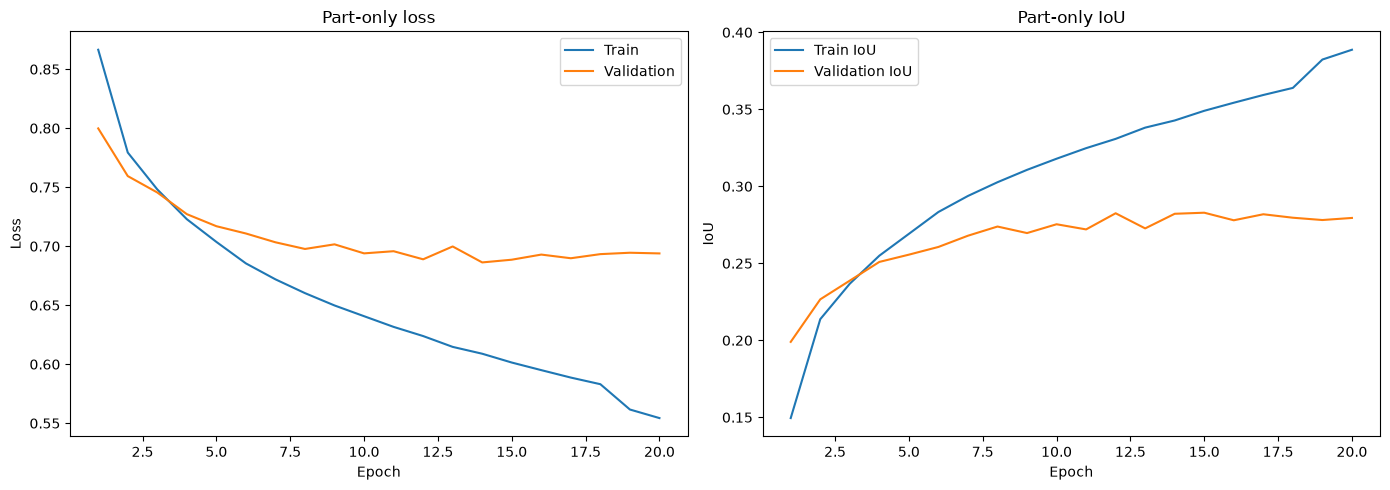

In [51]:
part_df = pd.DataFrame(
    part_only_history
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

axes[0].plot(
    part_df["epoch"],
    part_df["train_loss"],
    label="Train",
)

axes[0].plot(
    part_df["epoch"],
    part_df["val_loss"],
    label="Validation",
)

axes[0].set_xlabel(
    "Epoch"
)

axes[0].set_ylabel(
    "Loss"
)

axes[0].set_title(
    "Part-only loss"
)

axes[0].legend()

axes[1].plot(
    part_df["epoch"],
    part_df["train_iou"],
    label="Train IoU",
)

axes[1].plot(
    part_df["epoch"],
    part_df["val_iou"],
    label="Validation IoU",
)

axes[1].set_xlabel(
    "Epoch"
)

axes[1].set_ylabel(
    "IoU"
)

axes[1].set_title(
    "Part-only IoU"
)

axes[1].legend()

plt.tight_layout()
plt.show()

In [52]:
best_part_row = part_df.loc[
    part_df[
        "val_iou"
    ].idxmax()
]

best_part_row

epoch             15.000000
train_loss         0.601435
train_iou          0.349046
train_dice         0.453074
val_loss           0.688583
val_iou            0.282868
val_dice           0.372704
learning_rate      0.001000
seconds          106.413512
Name: 14, dtype: float64

In [53]:
object_mask_model, object_mask_history = (
    train_experiment(
        mode="object_mask",
        epochs=EPOCHS,
    )
)

[object_mask] Epoch 01/20 | train loss 0.8604 | train IoU 0.1531 | val loss 0.7940 | val IoU 0.2026 | val Dice 0.2809 | 103.0s
  -> saved new best checkpoint
[object_mask] Epoch 02/20 | train loss 0.7693 | train IoU 0.2196 | val loss 0.7469 | val IoU 0.2341 | val Dice 0.3179 | 100.1s
  -> saved new best checkpoint
[object_mask] Epoch 03/20 | train loss 0.7327 | train IoU 0.2460 | val loss 0.7263 | val IoU 0.2506 | val Dice 0.3389 | 102.0s
  -> saved new best checkpoint
[object_mask] Epoch 04/20 | train loss 0.7021 | train IoU 0.2683 | val loss 0.7096 | val IoU 0.2615 | val Dice 0.3518 | 103.6s
  -> saved new best checkpoint
[object_mask] Epoch 05/20 | train loss 0.6786 | train IoU 0.2858 | val loss 0.6938 | val IoU 0.2729 | val Dice 0.3632 | 105.6s
  -> saved new best checkpoint
[object_mask] Epoch 06/20 | train loss 0.6616 | train IoU 0.2987 | val loss 0.6853 | val IoU 0.2772 | val Dice 0.3683 | 105.4s
  -> saved new best checkpoint
[object_mask] Epoch 07/20 | train loss 0.6465 | trai

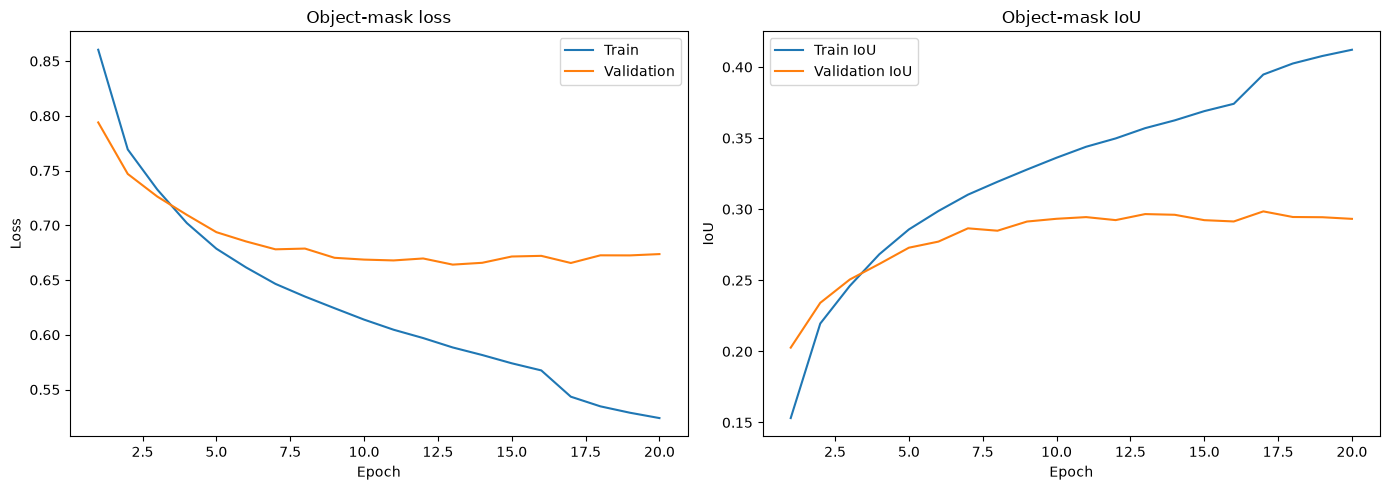

In [54]:
mask_df = pd.DataFrame(
    object_mask_history
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

axes[0].plot(
    mask_df["epoch"],
    mask_df["train_loss"],
    label="Train",
)

axes[0].plot(
    mask_df["epoch"],
    mask_df["val_loss"],
    label="Validation",
)

axes[0].set_title(
    "Object-mask loss"
)

axes[0].set_xlabel(
    "Epoch"
)

axes[0].set_ylabel(
    "Loss"
)

axes[0].legend()

axes[1].plot(
    mask_df["epoch"],
    mask_df["train_iou"],
    label="Train IoU",
)

axes[1].plot(
    mask_df["epoch"],
    mask_df["val_iou"],
    label="Validation IoU",
)

axes[1].set_title(
    "Object-mask IoU"
)

axes[1].set_xlabel(
    "Epoch"
)

axes[1].set_ylabel(
    "IoU"
)

axes[1].legend()

plt.tight_layout()
plt.show()

In [55]:
best_part = (
    part_df.loc[
        part_df["val_iou"].idxmax()
    ]
)

best_mask = (
    mask_df.loc[
        mask_df["val_iou"].idxmax()
    ]
)

validation_comparison = pd.DataFrame(
    [
        {
            "model": "DINO + CLIP",
            "best_epoch": (
                int(
                    best_part["epoch"]
                )
            ),
            "val_iou": (
                best_part["val_iou"]
            ),
            "val_dice": (
                best_part["val_dice"]
            ),
        },

        {
            "model": (
                "DINO + CLIP + Object Mask"
            ),
            "best_epoch": (
                int(
                    best_mask["epoch"]
                )
            ),
            "val_iou": (
                best_mask["val_iou"]
            ),
            "val_dice": (
                best_mask["val_dice"]
            ),
        },
    ]
)

validation_comparison

,model,best_epoch,val_iou,val_dice
0,DINO + CLIP,15,0.282868,0.372704
1,DINO + CLIP + Object Mask,17,0.298462,0.391325


In [56]:
def load_best_model(
    mode,
):

    checkpoint_path = (
        OUTPUT_ROOT
        / mode
        / "best.pt"
    )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )

    model = BaselinePartSegmenter(
        dino_encoder=dino,
        mode=mode,
        visual_dim=VISUAL_DIM,
        text_dim=TEXT_DIM,
    ).to(
        DEVICE
    )

    load_trainable_state(
        model,
        checkpoint,
    )

    model.eval()

    return (
        model,
        checkpoint,
    )

In [57]:
best_part_model, part_checkpoint = (
    load_best_model(
        "part_only"
    )
)

print(
    "Best epoch:",
    part_checkpoint["epoch"]
)

print(
    "Validation metrics:",
    part_checkpoint["val_metrics"]
)

Best epoch: 15
Validation metrics: {'loss': 0.6885833374376308, 'bce': 0.05257427492284466, 'dice_loss': 0.6360090615422723, 'iou': 0.2828683804523726, 'dice': 0.37270427729126704}


In [58]:
best_mask_model, mask_checkpoint = (
    load_best_model(
        "object_mask"
    )
)

print(
    "Best epoch:",
    mask_checkpoint["epoch"]
)

print(
    "Validation metrics:",
    mask_checkpoint["val_metrics"]
)

Best epoch: 17
Validation metrics: {'loss': 0.6655929152890959, 'bce': 0.05049243291685239, 'dice_loss': 0.6151004815564572, 'iou': 0.29846203321150977, 'dice': 0.39132461525668605}


In [59]:
@torch.no_grad()
def evaluate_model(
    model,
    loader,
):

    return run_epoch(
        model,
        loader,
        text_encoder,
        optimizer=None,
        scaler=None,
        threshold=MASK_THRESHOLD,
    )

In [60]:
part_seen_metrics = (
    evaluate_model(
        best_part_model,
        test_seen_loader,
    )
)

part_unseen_metrics = (
    evaluate_model(
        best_part_model,
        test_unseen_loader,
    )
)

print(
    "PART ONLY - TEST SEEN"
)

print(
    part_seen_metrics
)

print()

print(
    "PART ONLY - TEST UNSEEN"
)

print(
    part_unseen_metrics
)

PART ONLY - TEST SEEN
{'loss': 0.67327611388385, 'bce': 0.05791229132515356, 'dice_loss': 0.6153638224791292, 'iou': 0.29804697704400057, 'dice': 0.39413934565905967}

PART ONLY - TEST UNSEEN
{'loss': 0.943572298124489, 'bce': 0.14379330984966227, 'dice_loss': 0.7997789916595325, 'iou': 0.14098159356270581, 'dice': 0.2010196023262464}


In [61]:
mask_seen_metrics = (
    evaluate_model(
        best_mask_model,
        test_seen_loader,
    )
)

mask_unseen_metrics = (
    evaluate_model(
        best_mask_model,
        test_unseen_loader,
    )
)

print(
    "OBJECT MASK - TEST SEEN"
)

print(
    mask_seen_metrics
)

print()

print(
    "OBJECT MASK - TEST UNSEEN"
)

print(
    mask_unseen_metrics
)

OBJECT MASK - TEST SEEN
{'loss': 0.6481821738587965, 'bce': 0.050793311096456, 'dice_loss': 0.5973888596735875, 'iou': 0.31188363837615846, 'dice': 0.4103696594886135}

OBJECT MASK - TEST UNSEEN
{'loss': 0.7918769690909272, 'bce': 0.08646861649697357, 'dice_loss': 0.7054083526209655, 'iou': 0.21451853642247212, 'dice': 0.29711827819915615}


In [62]:
baseline_results = pd.DataFrame(
    [
        {
            "model": (
                "DINO + CLIP"
            ),

            "seen_iou": (
                part_seen_metrics[
                    "iou"
                ]
            ),

            "seen_dice": (
                part_seen_metrics[
                    "dice"
                ]
            ),

            "unseen_iou": (
                part_unseen_metrics[
                    "iou"
                ]
            ),

            "unseen_dice": (
                part_unseen_metrics[
                    "dice"
                ]
            ),
        },

        {
            "model": (
                "DINO + CLIP + Object Mask"
            ),

            "seen_iou": (
                mask_seen_metrics[
                    "iou"
                ]
            ),

            "seen_dice": (
                mask_seen_metrics[
                    "dice"
                ]
            ),

            "unseen_iou": (
                mask_unseen_metrics[
                    "iou"
                ]
            ),

            "unseen_dice": (
                mask_unseen_metrics[
                    "dice"
                ]
            ),
        },
    ]
)

baseline_results

,model,seen_iou,seen_dice,unseen_iou,unseen_dice
0,DINO + CLIP,0.298047,0.394139,0.140982,0.201020
1,DINO + CLIP + Object Mask,0.311884,0.410370,0.214519,0.297118


In [63]:
seen_improvement = (
    mask_seen_metrics["iou"]
    - part_seen_metrics["iou"]
)

unseen_improvement = (
    mask_unseen_metrics["iou"]
    - part_unseen_metrics["iou"]
)

print(
    f"Seen IoU improvement: "
    f"{seen_improvement:+.4f}"
)

print(
    f"Unseen IoU improvement: "
    f"{unseen_improvement:+.4f}"
)

Seen IoU improvement: +0.0138
Unseen IoU improvement: +0.0735


In [64]:
results_path = (
    OUTPUT_ROOT
    / "baseline_results.csv"
)

baseline_results.to_csv(
    results_path,
    index=False,
)

print(
    "Saved:",
    results_path
)

Saved: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/baseline_results.csv


In [65]:
@torch.no_grad()
def predict_one(
    model,
    sample,
):

    image = (
        sample["image"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    object_mask = (
        sample["object_mask"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    text_embedding = (
        text_encoder(
            [
                sample["query"]
            ]
        )
    )

    logits = model(
        image,
        text_embedding,
        object_mask,
    )

    probability = (
        torch.sigmoid(
            logits
        )[0, 0]
        .cpu()
    )

    prediction = (
        probability
        >= MASK_THRESHOLD
    )

    return (
        probability,
        prediction,
    )

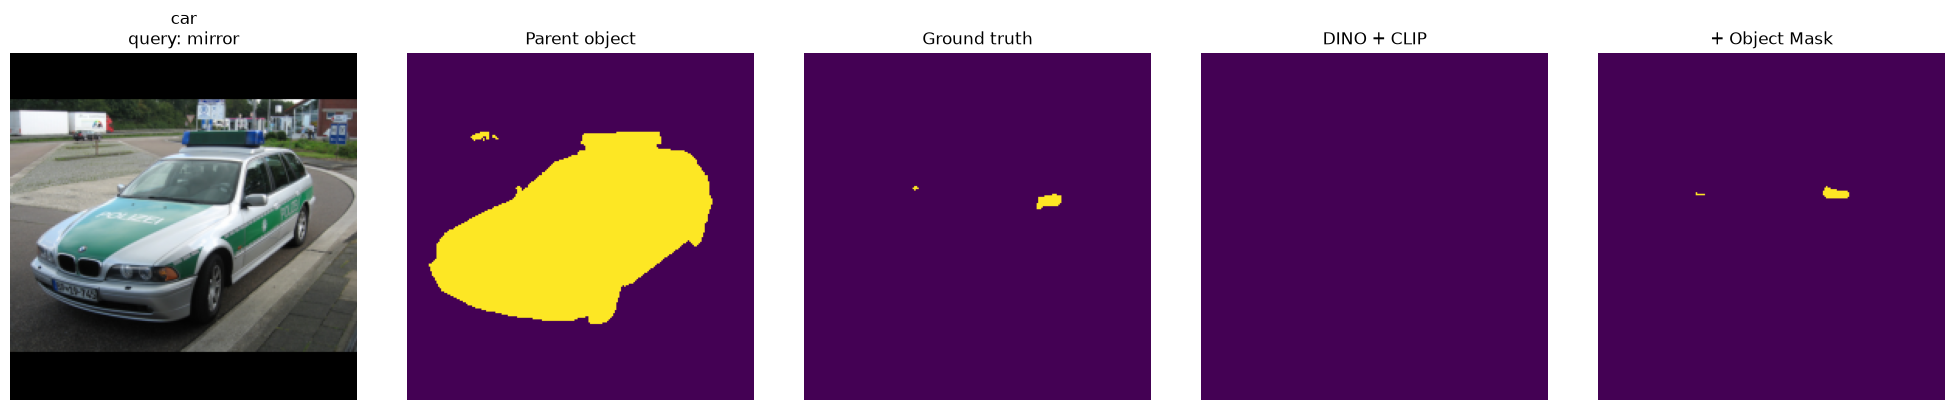

In [66]:
idx = random.randrange(
    len(test_unseen_dataset)
)

sample = (
    test_unseen_dataset[idx]
)

part_prob, part_pred = (
    predict_one(
        best_part_model,
        sample,
    )
)

mask_prob, mask_pred = (
    predict_one(
        best_mask_model,
        sample,
    )
)

fig, axes = plt.subplots(
    1,
    5,
    figsize=(20, 4),
)

axes[0].imshow(
    sample[
        "display_image"
    ].permute(
        1,
        2,
        0,
    )
)

axes[0].set_title(
    f"{sample['object_name']}\n"
    f"query: {sample['query']}"
)

axes[1].imshow(
    sample[
        "object_mask"
    ].squeeze()
)

axes[1].set_title(
    "Parent object"
)

axes[2].imshow(
    sample[
        "part_mask"
    ].squeeze()
)

axes[2].set_title(
    "Ground truth"
)

axes[3].imshow(
    part_pred
)

axes[3].set_title(
    "DINO + CLIP"
)

axes[4].imshow(
    mask_pred
)

axes[4].set_title(
    "+ Object Mask"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [67]:
def show_overlay(
    image,
    mask,
    title,
):

    image_np = (
        image
        .permute(1, 2, 0)
        .numpy()
    )

    mask_np = (
        mask.numpy()
    )

    plt.figure(
        figsize=(6, 6)
    )

    plt.imshow(
        image_np
    )

    plt.imshow(
        mask_np,
        alpha=0.45,
    )

    plt.title(
        title
    )

    plt.axis(
        "off"
    )

    plt.show()

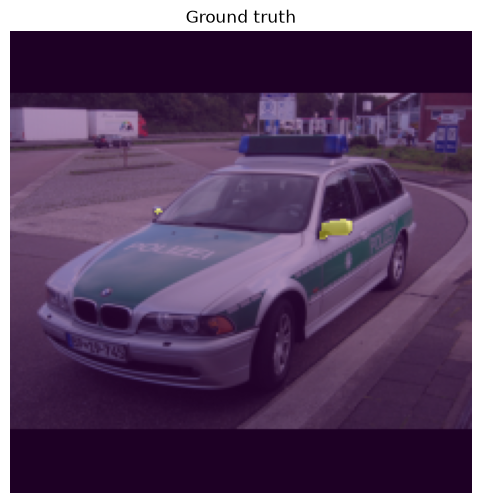

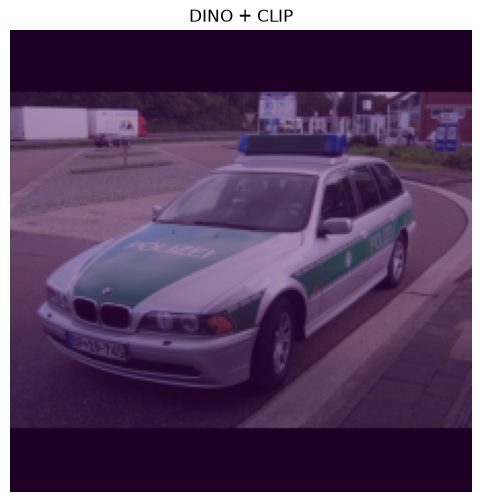

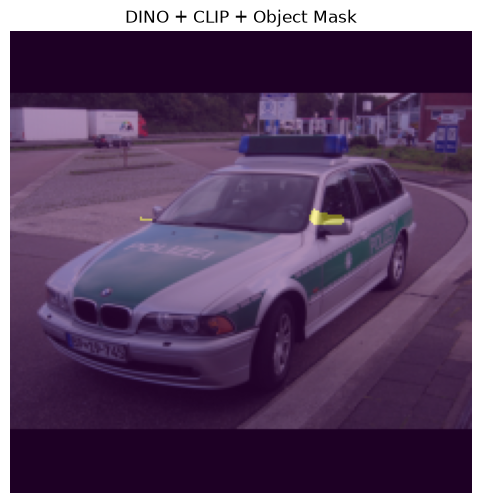

In [68]:
show_overlay(
    sample["display_image"],
    sample[
        "part_mask"
    ].squeeze(),
    "Ground truth",
)

show_overlay(
    sample["display_image"],
    part_pred,
    "DINO + CLIP",
)

show_overlay(
    sample["display_image"],
    mask_pred,
    "DINO + CLIP + Object Mask",
)

In [69]:
summary = {
    "part_only": {
        "seen": (
            part_seen_metrics
        ),
        "unseen": (
            part_unseen_metrics
        ),
    },

    "object_mask": {
        "seen": (
            mask_seen_metrics
        ),
        "unseen": (
            mask_unseen_metrics
        ),
    },

    "object_mask_iou_gain": {
        "seen": (
            seen_improvement
        ),
        "unseen": (
            unseen_improvement
        ),
    },
}

summary_path = (
    OUTPUT_ROOT
    / "baseline_summary.json"
)

with open(
    summary_path,
    "w",
) as f:

    json.dump(
        summary,
        f,
        indent=2,
    )

print(
    "Saved:",
    summary_path
)

Saved: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/baseline_summary.json


# Notebook 03 Summary

Two controlled segmentation baselines have now been trained.

## Experiment 1 — DINO + CLIP

The model receives:

- frozen DINOv2 patch features;
- frozen CLIP text embedding.

No parent-object information is provided.

This measures how much text-conditioned part segmentation can be achieved
from pretrained visual-language representations alone.

---

## Experiment 2 — DINO + CLIP + Object Mask

The architecture is identical to Experiment 1.

The only difference is that the decoder receives the parent-object mask.

This measures the value of explicitly identifying the relevant parent object.

---

## Important

No explicit coordinate information has been used yet.

Therefore these models provide the clean baselines needed for the next study.

The next experiments will compare:

1. Object Mask only
2. Object Mask + Absolute X/Y
3. Object Mask + Object-Relative U/V

This will answer whether:

- DINOv2 already contains sufficient spatial information;
- explicit coordinates add complementary information;
- object-relative coordinates are more useful than ordinary image coordinates.